<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_25-26/blob/main/notebooks/Lab-1.Data_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generazione e visualizzazione di dati per regressione e classificazione

**Obiettivo**: generare dati sintetici sia per task di regressione che di classificazione.

In [1]:
#%pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Generazione dei dati: regressione, lineare
============================

Il modello è $y=wx + \varepsilon$ con $\varepsilon \sim \mathcal{N}(0, \sigma)$

In [3]:
def datagen(d, points, m, M, w, sigma):
    """
    Parametri
    ----------
    - d : int 
        Dimensione di ogni campione di dati

    - points : int 
        Numero di punti da generare

    - m : float 
        Limite inferiore per il dominio dei punti dati

    - M : float 
        Limite superiore per il dominio dei punti dati

    - w : array di float di dim d 
        Vettore dei pesi del modello lineare

    - sigma : float 
        Deviazione standard del rumore eps
    """
    
    X = np.zeros((points, d))
    for i in range(points):
        X[i,:] = np.random.uniform(m, M, d)
    
    # In alternativa potevo usare: X = np.random.uniform(low = m, high = M, size = (points,d))
    
    eps = np.random.normal(0, sigma, points)
    y = np.dot(X, w) + eps
    return X, y

Il codice Python appena fornito definisce una funzione chiamata `datagen` che genera punti dati casuali per un modello di regressione lineare aggiungendo un po' di rumore. Ecco una spiegazione passo passo di cosa faccio nel codice:

1. Creo un array vuoto `X` con dimensioni `(points, d)` per memorizzare i punti dati generati. Ogni riga di questo array rappresenta un campione di dati e ogni colonna rappresenta una feature.

2. Uso un ciclo `for` per iterare su ogni punto dati da generare (`points` iterazioni).

3. All'interno del ciclo, genero un campione di dati casuale e lo assegno all'i-esima riga dell'array `X`. Genero questo campione casuale usando `np.random.uniform(m, M, d)`, che crea `n*d` valori casuali nell'intervallo `[m, M]` per ogni feature del punto dati.

4. Genero un array `eps` di rumore casuale usando `np.random.normal(0, sigma, points)`. Questo array ha la stessa lunghezza del numero di punti dati e rappresenta un rumore casuale con distribuzione normale e con la deviazione standard specificata `sigma`.

5. Genero la variabile target `y` per ogni punto dati calcolando il prodotto scalare tra il punto dati `X[i]` e il vettore dei pesi `w`. Poi, vi aggiungo il corrispondente valore di rumore `eps[i]`. Questo simula un modello di regressione lineare in cui la variabile target è una combinazione lineare delle feature con l'aggiunta di rumore Gaussiano.

In [4]:
# Esempio di utilizzo
d = 1
w = np.random.normal(0, 1, d)
sigma = 1
points = 100
m = -10
M = 10

X, y = datagen(d, points, m, M, w, sigma)

print(f"Forma dell'array di dati generato X: {X.shape}")
print(f"Forma dell'array di dati generato y: {y.shape}")

Forma dell'array di dati generato X: (100, 1)
Forma dell'array di dati generato y: (100,)


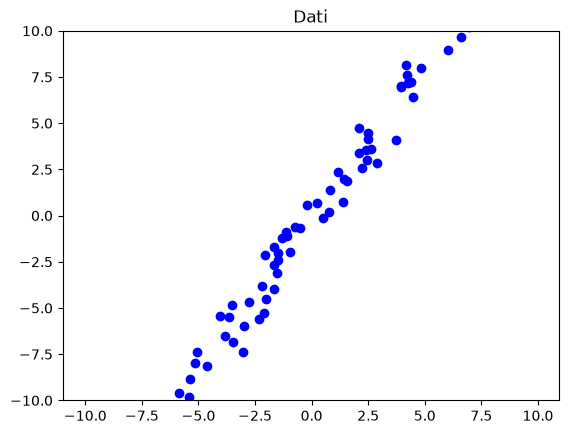

In [5]:
# Disegno il dataset generato
fig, ax = plt.subplots()
ax.scatter(X, y, c='b')
ax.set_title('Dati')
plt.ylim([m, M])

plt.show()

1. Aggiungo un livello diverso di rumore (come ottengo dati senza rumore?) e la funzione vera al grafico

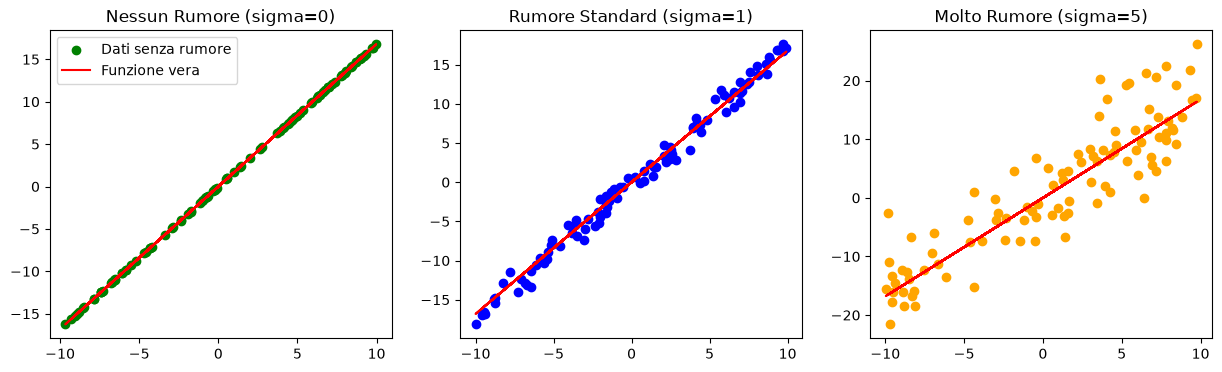

In [6]:
# Completo l'esercizio calcolando varianze diverse per il rumore
X_no_noise, y_no_noise = datagen(d, points, m, M, w, 0) # Dati senza rumore (sigma = 0)
X_high_noise, y_high_noise = datagen(d, points, m, M, w, 5) # Dati con molto rumore (sigma = 5)

# Traccio i risultati a confronto
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Grafico 1: Nessun rumore (sigma=0) -> coincide perfettamente con la funzione vera
ax[0].scatter(X_no_noise, y_no_noise, c='g', label='Dati senza rumore')
ax[0].plot(X_no_noise, np.dot(X_no_noise, w), c='r', label='Funzione vera')
ax[0].set_title('Nessun Rumore (sigma=0)')
ax[0].legend()

# Grafico 2: Rumore Standard (sigma=1)
ax[1].scatter(X, y, c='b')
ax[1].plot(X, np.dot(X, w), c='r', label='Funzione vera')
ax[1].set_title('Rumore Standard (sigma=1)')

# Grafico 3: Molto Rumore (sigma=5) -> i dati sono molto più dispersi
ax[2].scatter(X_high_noise, y_high_noise, c='orange')
ax[2].plot(X_high_noise, np.dot(X_high_noise, w), c='r', label='Funzione vera')
ax[2].set_title('Molto Rumore (sigma=5)')

plt.show()

Generazione dei dati: classificazione
=========================

Voglio generare dati 2D per la classificazione sotto forma di 2 (o più) nuvole gaussiane con medie e varianze specifiche.

In [7]:
def mixGauss(means, sigmas, n):
    """
    Parametri
    ----------
    - means : matrice/lista di float di dim n_classes x dim_data (d) 
         Medie delle funzioni Gaussiane

    - sigmas : array/lista di float di dim n_classes 
        Deviazioni standard delle funzioni Gaussiane

    - n : int 
        Numero di punti per ciascuna classe
    """
    means = np.array(means)
    sigmas = np.array(sigmas)

    d = np.shape(means)[1] # la matrice delle medie è n_classes x dim_data
    num_classes = sigmas.size # il numero di varianze corrisponde al numero di classi

    data = np.full((n * num_classes, d), np.inf)
    labels = np.zeros(n * num_classes)

    # itero sulle classi
    for idx, sigma in enumerate(sigmas):
        # genero n punti attorno a means[idx] con covarianza sigma[idx]
        data[idx * n:(idx + 1) * n] = np.random.multivariate_normal(
            mean=means[idx], cov=np.eye(d) * sigmas[idx] ** 2, size=n)
        labels[idx * n:(idx + 1) * n] = idx

    if(num_classes == 2):
        labels[labels == 0] = -1

    return data, labels

Il seguente codice definisce una funzione Python chiamata `mixGauss` che genera dati campionati da una mistura di distribuzioni Gaussiane.

1. Converto gli input `means` e `sigmas` in array NumPy per facilitare l'elaborazione successiva.

2. Inizializzo la variabile `d` con la dimensione dei dati `dim_data` presente in `means`. Questo valore mi rappresenta il numero di dimensioni dei dati.

3. Inizializzo la variabile `num_classes` con la dimensione di `sigmas`, che mi rappresenta il numero di classi delle distribuzioni Gaussiane.

4. Creo una matrice di dati vuota `data` con dimensioni `(n * num_classes, d)` e la riempio inizialmente con `np.inf`. Userò questa matrice per memorizzare i punti dati che andrò a generare.

5. Creo un array di etichette vuoto `labels` con dimensioni `n * num_classes` e lo inizializzo con zeri. Questo array memorizzerà le etichette di classe per i punti dati generati.

6. Itero sulle classi usando un ciclo `for` con un indice `idx` e la corrispondente deviazione standard `sigma` dalla lista `sigmas`.

7. All'interno del ciclo, per ogni classe, genero `n` punti dati attorno alla media `means[idx]` con una matrice di covarianza `np.eye(d) * sigmas[idx] ** 2`. Utilizzo la funzione `np.random.multivariate_normal` a questo scopo. Essa genera campioni casuali da una distribuzione Gaussiana multivariata.

8. Memorizzo i punti dati generati nell'array `data` dall'indice `idx * n` a `(idx + 1) * n`, e imposto le loro etichette nell'array `labels` all'indice di classe `idx`.

9. Se ci sono solo due classi (`num_classes == 2`), gestisco un caso speciale: converto le etichette in modo che tutte le istanze etichettate come `0` diventino `-1`. Questa è un'operazione che svolgo comunemente nei task di classificazione binaria.

10. La funzione restituisce due array: `data`, che contiene i punti dati generati, e `labels`, che contiene le etichette di classe corrispondenti.

In [8]:
# Esempio di utilizzo
means = [[3,0],[0,6]]
sigmas = [0.9,0.9]
n = 100

X, labels = mixGauss(means, sigmas, n)

/tmp/ipykernel_2347/2564294582.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


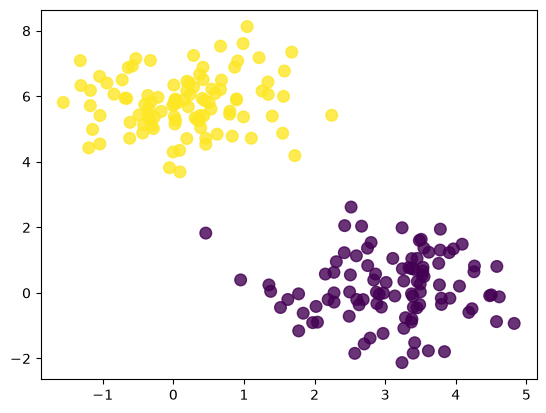

In [9]:
# Disegno il dataset generato
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], s=70, c=labels, alpha=0.8)
fig.show()

Rumore sulle etichette (Label Noise)
==========

Aggiungo un po' di rumore al dataset per la classificazione binaria invertendo casualmente alcune etichette.

In [10]:
def labelsnoise(perc, labels):
    """
    Parametri
    ----------
    - perc : float 
        Percentuale di etichette da invertire
        
    - labels: array di int di dim n_classes 
        Array contenente gli indici delle etichette
    """
    points = np.shape(labels)[0]
    noisylabels = np.copy(np.squeeze(labels))
    n_flips = int(np.floor(points * perc / 100)) # floor: arrotondo all'intero più vicino per difetto
    idx_to_flip = np.random.choice(points, size=n_flips, replace=False) # replace è False poiché lo stesso indice non può essere scelto due volte
    noisylabels[idx_to_flip] = -noisylabels[idx_to_flip] # per la classificazione binaria, questo trasforma -1 in 1 e viceversa
    return noisylabels


Il codice fornito definisce una funzione Python chiamata `labelsnoise` che introduce rumore in un set di etichette invertendone una percentuale specificata.

1. Determino il numero di punti dati, `points`, tramite la lunghezza dell'array `labels` usando `np.shape(labels)[0]`.

2. Creo una copia dell'array `labels` e la salvo nella variabile `noisylabels` usando `np.copy(np.squeeze(labels))`. Modificherò questa copia per introdurre rumore senza alterare l'array `labels` originale.

3. Calcolo il numero di etichette da invertire, `n_flips`, come intero arrotondando per difetto (con floor) il risultato di `(points * perc / 100)`. Questo calcolo mi determina quante etichette verranno invertite in base alla percentuale specificata.

4. Genero un array di indici casuali da invertire, `idx_to_flip`, usando `np.random.choice(points, size=n_flips, replace=False)`. L'argomento `replace=False` mi assicura che lo stesso indice non possa essere scelto più di una volta, evitando duplicati.

5. Inverto le etichette selezionate agli indici specificati in `idx_to_flip` cambiandone il segno. Per etichette binarie (es. -1 e 1), questa operazione mi trasforma -1 in 1 e viceversa.

In [11]:
# Esempio di utilizzo
noisylabels = labelsnoise(50, labels)
noisylabels

array([ 1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
       -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., -1., -1.,  1., -1.,
        1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1., -1., -1.,  1.,
        1.,  1.,  1.,  1., -1., -1., -1.,  1.,  1., -1., -1., -1., -1.,
        1., -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1.,
        1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,
       -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1., -1.,  1.,
       -1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1., -1.,  1., -1.,
       -1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,
       -1.,  1.,  1., -1.,  1., -1., -1.,  1., -1., -1.,  1., -1.,  1.,
       -1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1.,
        1.,  1., -1., -1., -1., -1.,  1., -1., -1., -1.,  1.,  1., -1.,
        1.,  1., -1.,  1., -1., -1.,  1.,  1.,  1., -1., -1., -1.,  1.,
        1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1., -1

/tmp/ipykernel_2347/2363527531.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


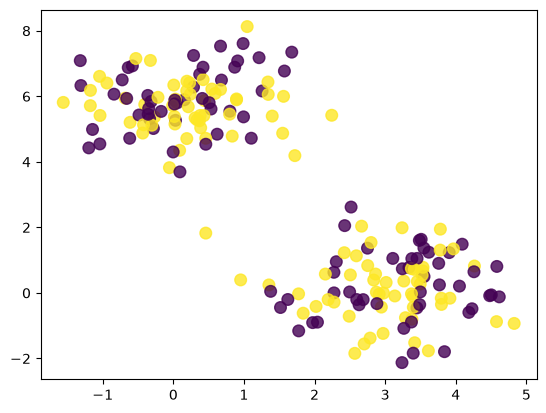

In [12]:
# Disegno il dataset generato
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], s=70, c=noisylabels, alpha=0.8)
fig.show()

Alternativa per la classificazione binaria: lineare
==================================

Genero un dataset per la classificazione in cui i punti sono separati linearmente, ovvero esiste una retta $y = ax + b$ che separa nettamente le classi.

In [13]:
def binary(a, b, points, m, M, d):
    """
    Parametri
    ----------
    - a : float
        Coefficiente angolare (pendenza) della retta di separazione

    - b : float
        Intercetta della retta di separazione

    - points : int
        Numero di punti da generare

    - m : float
        Limite inferiore per il dominio dei punti dati
        
    - M : float
        Limite superiore per il dominio dei punti dati

    - d : int
        Dimensione di ogni campione di dati
    """
    X = np.zeros((points,d))
    labels = np.zeros(points)

    for i in range(points):
        X[i,:] = np.random.uniform(m, M, d)

    labels[X[:,1]-a*X[:,0]-b>=0] = 1
    labels[X[:,1]-a*X[:,0]-b<0] = -1
    return X, labels

Il codice fornito definisce una funzione Python chiamata `binary` che genera punti dati per un problema di classificazione binaria basato su un confine decisionale lineare.

1. Creo una matrice di dati vuota `X` con dimensioni `(points, d)` per memorizzare i punti dati generati.

2. Creo un array di etichette vuoto `labels` con dimensione `points` per memorizzare le etichette di classe per i punti dati generati.

3. Un ciclo `for` itera su ogni punto dati da generare (`points` iterazioni).

4. All'interno del ciclo, per ogni punto dati, genero `d` valori casuali nell'intervallo `[m, M]` per ogni feature usando `np.random.uniform(m, M, d)`. Questi valori casuali mi rappresentano i valori delle feature del punto dati, e vengono assegnati all'i-esima riga dell'array `X`.

5. Determino l'etichetta di classe per ogni punto dati in base alla sua posizione relativa alla retta di separazione definita da `a` e `b`. Se il punto dati si trova sopra la retta (cioè, `X[:, 1] - a * X[:, 0] - b >= 0`), imposto la sua etichetta a `1`. Se si trova sotto la retta (cioè, `X[:, 1] - a * X[:, 0] - b < 0`), imposto la sua etichetta a `-1`. Questo mi crea effettivamente un problema di classificazione binaria in cui i punti dati sono separati in due classi in base alla loro posizione relativa al confine decisionale lineare.

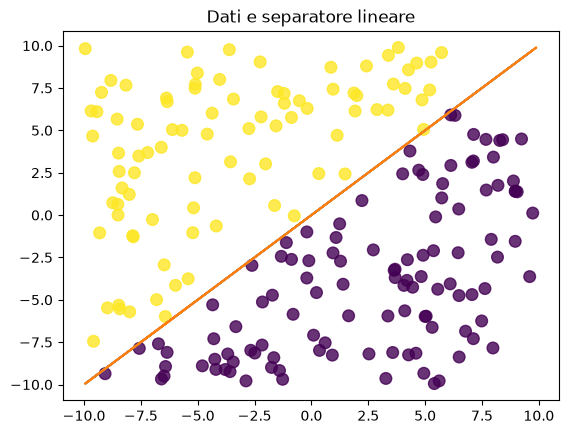

In [14]:
# Esempio di utilizzo
a=1
b=0
d=2
points=200
m=-10
M=10

X,labels=binary(a,b,points,m,M,d)

# Disegno il dataset generato
fig,ax=plt.subplots()
ax.scatter(X[:,0],X[:,1],s=70, c=labels, alpha=0.8)
ax.plot(X,a*X+b)
ax.set_title('Dati e separatore lineare')
plt.show()

Alternativa per la classificazione binaria: non lineare
==============================================

Aggiungo un po' di rumore al dataset di classificazione binaria invertendo casualmente alcune etichette;

Genero dataset di classificazione binaria separati da funzioni non lineari.

In [15]:
def flipLabels(perc, Y):
    """
    Parametri
    ----------
    - perc : float
        Percentuale di etichette da invertire
        
    - Y: array di int di dim n_points
        Array contenente l'indice di classe di ogni punto dati
    """
    if perc < 1 or perc > 100:
        print("p dovrebbe essere un valore percentuale tra 0 e 100.")
        return -1

    if any(np.abs(Y) != 1):
        print("I valori di Y dovrebbero essere +1 o -1.")
        return -1

    Y_noisy = np.copy(np.squeeze(Y))
    if Y_noisy.ndim > 1:
        print("Per favore, fornisci un array di etichette con una sola dimensione")
        return -1

    n = Y_noisy.size
    n_flips = int(np.floor(n * perc / 100))
    idx_to_flip = np.random.choice(n, size=n_flips, replace=False)
    Y_noisy[idx_to_flip] = -Y_noisy[idx_to_flip]

    return Y_noisy

Il codice fornito definisce una funzione Python chiamata `flipLabels` che introduce rumore in un problema di classificazione binaria invertendo una percentuale specificata di etichette di classe.

1. Eseguo diversi controlli sui parametri di input per assicurarmi che siano validi e che l'operazione possa procedere in modo sicuro.

2. Creo una copia dell'array di etichette di input, `Y`, e la salvo nella variabile `Y_noisy`. Uso la funzione `squeeze` per rimuovere le dimensioni di grandezza 1, e `copy` mi assicura che l'array originale non venga modificato.

3. Controllo se la dimensione dell'array `Y_noisy` è maggiore di 1 (cioè, ha più di una dimensione). Se l'array di input ha più di una dimensione, stampo un messaggio di errore e restituisco `-1`.

4. Determino il numero totale di punti dati, `n`, in base alla grandezza dell'array `Y_noisy`.

5. Calcolo il numero di etichette da invertire, `n_flips`, come intero arrotondando per difetto il risultato di `(n * perc / 100)`.

8. Genero un array di indici casuali da invertire, `idx_to_flip`, usando `np.random.choice(n, size=n_flips, replace=False)`.

9. Inverto le etichette selezionate agli indici specificati in `idx_to_flip` cambiandone semplicemente il segno.

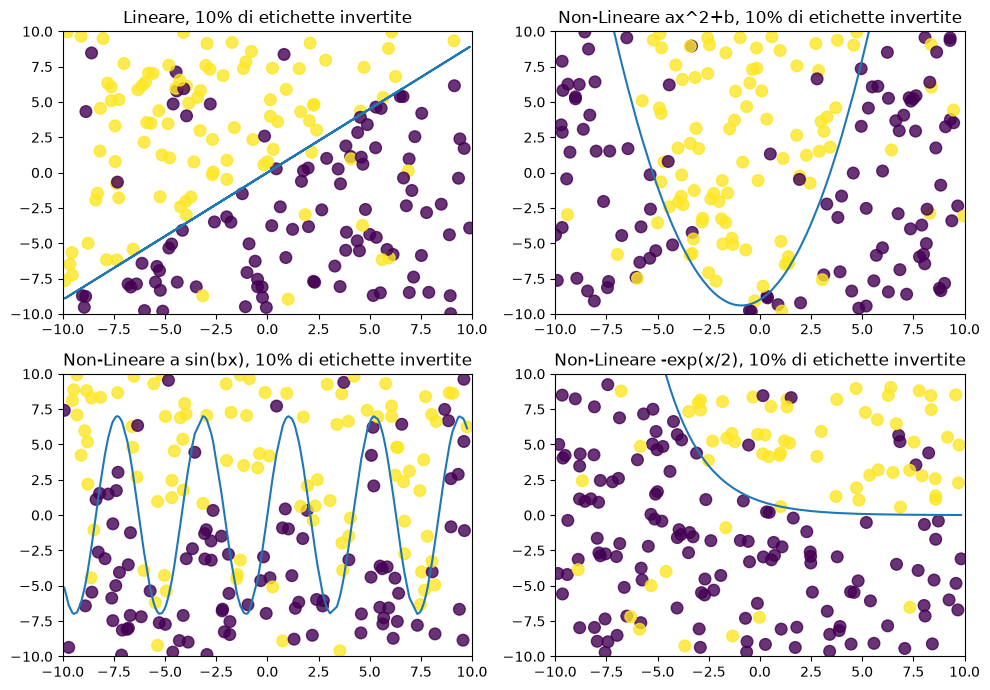

In [16]:
n = 200 # numero di punti per classe
D = 2 # dimensione dei punti

fig = plt.figure(figsize=(10,7))
ax0 = fig.add_subplot(2, 2, 1)
ax1 = fig.add_subplot(2, 2, 2)
ax2 = fig.add_subplot(2, 2, 3)
ax3 = fig.add_subplot(2, 2, 4)


# caso lineare
m = 0.9
q = 0

# limiti (assumo che siano gli stessi per tutte le dimensioni)
low_D = -10
high_D = 10

X = np.zeros((n, D))
Y = np.zeros(n)

# campionamento delle X
for i in range(D):
    X[:,i] = np.random.uniform(low_D, high_D, size=n)

# assegno le etichette a seconda della posizione del campione rispetto al separatore lineare
Y[X[:,1] - (X[:,0] * m + q) > 0] = 1
Y[Y==0] = -1

# aggiungo un po' di rumore
Yn = flipLabels(10, Y)

# traccio i campioni e il separatore
ax0.set_title("Lineare, 10% di etichette invertite")
ax0.scatter(X[:,0], X[:,1], s=70, c=Yn, alpha=0.8)
ax0.plot(X[:,0], X[:,0] * m + q)
ax0.set_xlim((low_D, high_D))
ax0.set_ylim((low_D, high_D))


# separatori non lineari caso 1

a = 0.5
b = 0.9
c = -9

X = np.zeros((n, D))
Y = np.zeros(n)

for i in range(D):
    X[:,i] = np.random.uniform(low_D, high_D, size=n)

Y[X[:,1] - (X[:,0]**2 * a + X[:,0]*b + c) > 0] = 1
Y[Y==0] = -1

Yn = flipLabels(10, Y)

ax1.set_title("Non-Lineare ax^2+b, 10% di etichette invertite")
ax1.scatter(X[:,0], X[:,1], s=70, c=Yn, alpha=0.8)
ax1.plot(np.sort(X[:,0]), np.sort(X[:,0])**2 * a + np.sort(X[:,0])*b + c)
ax1.set_xlim((low_D, high_D))
ax1.set_ylim((low_D, high_D))

# caso non lineare 2

alpha = 7
beta = 1.5

X = np.zeros((n, D))
Y = np.zeros(n)

for i in range(D):
    X[:,i] = np.random.uniform(low_D, high_D, size=n)

Y[X[:,1] - alpha*np.sin(beta*X[:,0]) > 0] = 1
Y[Y==0] = -1

Yn = flipLabels(10, Y)

ax2.set_title("Non-Lineare a sin(bx), 10% di etichette invertite")
ax2.scatter(X[:,0], X[:,1], s=70, c=Yn, alpha=0.8)
ax2.plot(np.sort(X[:,0]), alpha*np.sin(beta*np.sort(X[:,0])))
ax2.set_xlim((low_D, high_D))
ax2.set_ylim((low_D, high_D))

# caso non lineare 3

alpha = 7
beta = 0.5

X = np.zeros((n, D))
Y = np.zeros(n)

for i in range(D):
    X[:,i] = np.random.uniform(low_D, high_D, size=n)

Y[X[:,1] - np.exp(-X[:,0]/2) > 0] = 1
Y[Y==0] = -1

Yn = flipLabels(10, Y)

ax3.set_title("Non-Lineare -exp(x/2), 10% di etichette invertite")
ax3.scatter(X[:,0], X[:,1], s=70, c=Yn, alpha=0.8)
ax3.plot(np.sort(X[:,0]), np.exp(-np.sort(X[:,0]/2)))
ax3.set_xlim((low_D, high_D))
ax3.set_ylim((low_D, high_D))

plt.tight_layout()

Più di 2 Gaussiane
===================

Genero dati 2D per la classificazione (binaria) sotto forma di più di $2$ nuvole gaussiane con medie e varianze specifiche.

**Suggerimento**: prima genero il dataset con 4 classi, poi trasformo le etichette per ottenere le etichette binarie... la funzione `np.mod()` potrebbe essermi utile!

In [17]:
# utilizzo della funzione np.mod()
x = np.array([0, 2, 2, 1, 0, 3]) # array di 4 etichette
y = np.mod(x, 2) # trasformo le etichette in modo che ora siano binarie
print(y)

[0 0 0 1 0 1]


In [18]:
# da etichette {0, 1} a etichette {-1, 1}
z = 2 * y - 1
print(z)

[-1 -1 -1  1 -1  1]


In [19]:
# genero due dataset: binario (2 classi) e non binario (4 classi)
# classificazione con più di due gaussiane
mu = [[0,0], [0,1], [1,1], [1,0]] # 4 classi, punti a 2 dimensioni
sigma = [0.2, 0.2, 0.2, 0.2] # 4 classi
X, y = mixGauss(mu, sigma, 200)

# trasformo y in modo che mi rappresenti un problema di classificazione binaria per lo stesso dataset
y_bin = 2 * np.mod(y, 2) - 1

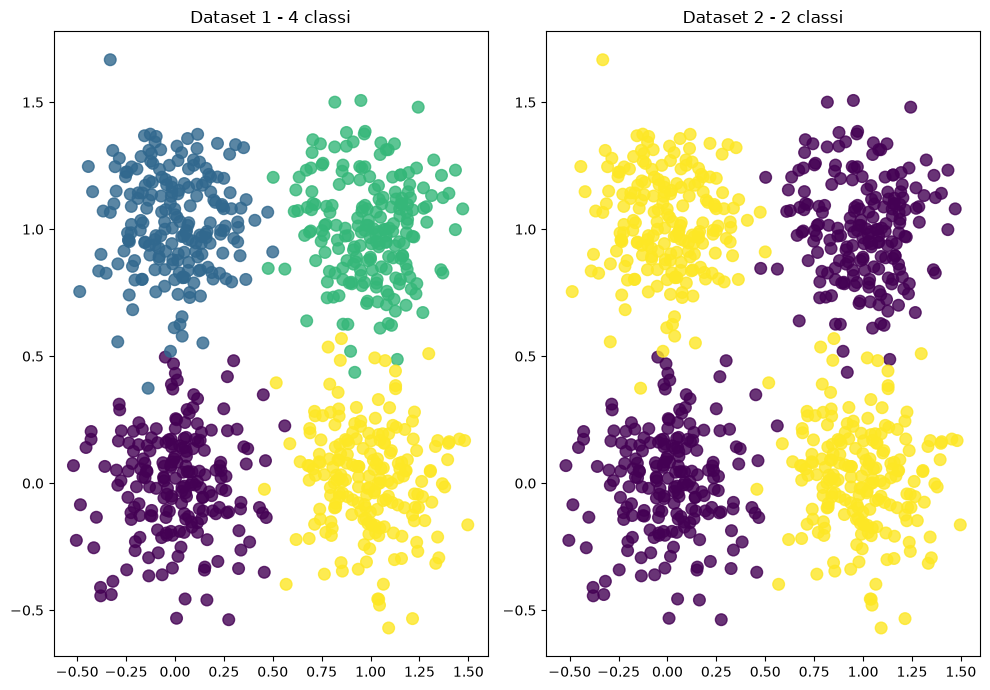

In [20]:
# disegno i due dataset generati
fig = plt.figure(figsize=(10,7))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

ax0.set_title("Dataset 1 - 4 classi")
ax0.scatter(X[:, 0], X[:, 1], s=70, c=y, alpha=0.8)

ax1.set_title("Dataset 2 - 2 classi")
ax1.scatter(X[:, 0], X[:, 1], s=70, c=y_bin, alpha=0.8)

plt.tight_layout()

Estendo l'inversione (flipping) a più gaussiane

In [21]:
# posso usare di nuovo la funzione np.mod()
n_classes = 4
y = np.random.choice(n_classes, size=10, replace=True) # genero un array casuale di etichette
print(y)
y_flip = np.mod(y + 1, n_classes) # aggiungo 1 in modo che tutte le etichette cambino effettivamente
print(y_flip)

[1 0 2 2 1 1 1 1 2 0]
[2 1 3 3 2 2 2 2 3 1]


In [22]:
# se non aggiungo 1, le etichette non cambiano
y_bad_flip = np.mod(y, n_classes)
print(y)
print(y_bad_flip)

[1 0 2 2 1 1 1 1 2 0]
[1 0 2 2 1 1 1 1 2 0]


In [23]:
def flipLabels_multipleGaussian(perc, Y):
    """
    Parametri
    ----------
    - perc : float
        Percentuale di etichette da invertire
        
    - Y: array di int di dim n_points
        Array contenente l'indice di classe di ogni punto dati
    """
    if perc < 1 or perc > 100:
        print("p dovrebbe essere un valore percentuale compreso tra 0 e 100.")
        return -1

    Y_noisy = np.copy(np.squeeze(Y))
    if Y_noisy.ndim > 1:
        print("Per favore, fornisci un array di etichette con una sola dimensione")
        return -1

    n = Y_noisy.size
    n_flips = int(np.floor(n * perc / 100))
    idx_to_flip = np.random.choice(n, size=n_flips, replace=False)
    
    # ancora una volta posso usare np.mod()
    n_classes = len(np.unique(Y, return_counts=False))
    Y_noisy[idx_to_flip] = np.mod(Y_noisy[idx_to_flip] + 1, n_classes)
    if n_classes == 2:
      Y_noisy[idx_to_flip] = -Y_noisy[idx_to_flip]

    return Y_noisy

Il codice fornito definisce una funzione Python chiamata `flipLabels_multipleGaussian` che introduce rumore in un set di etichette di classe. Questa funzione è progettata per task di classificazione multi-classe e mi introduce il rumore invertendo una percentuale specificata di etichette.

1. Eseguo diversi controlli sui parametri di input per assicurarmi che siano validi e che l'operazione possa procedere in modo sicuro.

2. Creo una copia dell'array di etichette di input, `Y`, e la memorizzo nella variabile `Y_noisy`.

3. Determino il numero totale di punti dati, `n`, in base alla dimensione dell'array `Y_noisy`.

4. Calcolo il numero di etichette da invertire, `n_flips`, come intero arrotondando per difetto il risultato di `(n * perc / 100)`.

5. Genero un array di indici casuali da invertire, `idx_to_flip`, usando `np.random.choice(n, size=n_flips, replace=False)`.

6. Le etichette selezionate agli indici specificati in `idx_to_flip` vengono invertite usando l'operazione modulo `np.mod(Y_noisy[idx_to_flip] + 1, n_classes)`, dove `n_classes` mi rappresenta il numero di classi univoche nell'array `Y_noisy`. Questa operazione mi ruota efficacemente le etichette di classe per introdurre il rumore.

7. Se il numero di classi, `n_classes`, è uguale a 2 (indicando un task di classificazione binaria), eseguo un passaggio aggiuntivo: converto le etichette nei loro equivalenti negativi.

8. La funzione mi restituisce l'array `Y_noisy` modificato, che contiene le etichette con il rumore introdotto.

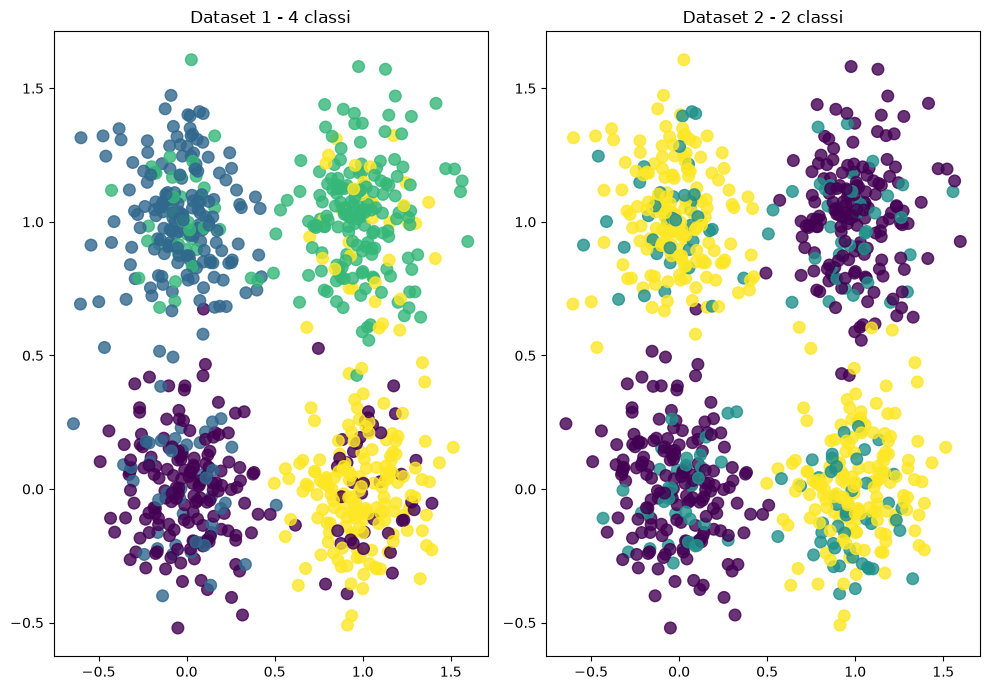

In [24]:
# esempio di utilizzo
X, y = mixGauss(mu, sigma, 200)
y_bin = 2 * np.mod(y, 2) - 1
p = 20 # inverto il 20% delle etichette
y_noisy = flipLabels_multipleGaussian(p, y)
y_bin_noisy = flipLabels_multipleGaussian(p, y_bin)

# disegno i due dataset generati
fig = plt.figure(figsize=(10,7))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

ax0.set_title("Dataset 1 - 4 classi")
ax0.scatter(X[:, 0], X[:, 1], s=70, c=y_noisy, alpha=0.8)

ax1.set_title("Dataset 2 - 2 classi")
ax1.scatter(X[:, 0], X[:, 1], s=70, c=y_bin_noisy, alpha=0.8)

plt.tight_layout()

## Piccolo add-on

*Se voglio un modo più semplice (ma forse meno efficace) per creare il mio dataset senza definire funzioni particolari...*

In [25]:
import sys, drawdata
print(sys.executable)
print(drawdata.__file__)

/mnt/c/Users/kokin/Desktop/Prog. Script/Programming_Lab-2_PY-/.venv/bin/python
/mnt/c/Users/kokin/Desktop/Prog. Script/Programming_Lab-2_PY-/.venv/lib/python3.14/site-packages/drawdata/__init__.py


In [26]:
%pip install anywidget ipywidgets drawdata
# ... e riavvio vs code.

Note: you may need to restart the kernel to use updated packages.


In [27]:
from drawdata import ScatterWidget

widget = ScatterWidget()
widget

In [ ]:
import pandas as pd
data = widget.data_as_pandas

In [28]:
data

NameError: name 'data' is not defined

NameError: name 'data' is not defined

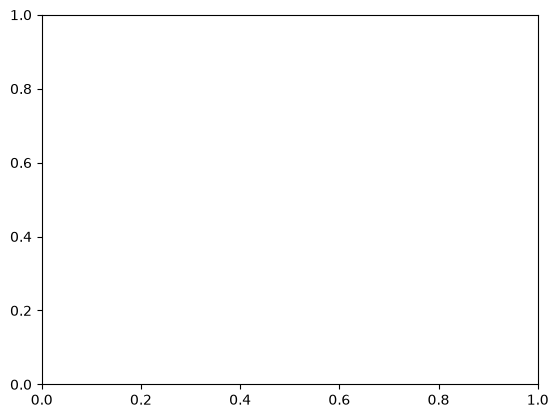

In [29]:
fig, ax = plt.subplots()
for cat, g in data.groupby("label"):
    ax.scatter(g["x"], g["y"], label=cat, s=15, alpha=0.7)
ax.legend()
ax.grid()
plt.show()